# Study 223 -- Same-Month Seasonality
## For the quants: signal construction, HAC tests, bootstrap CI, sub-period decay

*Part of [Open-Alpha-Lab](../../../README.md). See the [desk methodology](../../../METHODOLOGY.md).*


## Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from same_month_seasonality import data, strategy as st

CACHE_PATH = data.MONTHLY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    prices = data.fetch_monthly(fetch=False, cache_path=CACHE_PATH)
    sig = st.same_month_signal(prices, min_years=5)
    res = st.decile_returns(sig, prices, q=0.10)
    spread = res["spread"].dropna()
    high_xret = (res["high"] - res["market"]).dropna()
    print(f"Real panel loaded: {prices.shape[0]} months x {prices.shape[1]} tickers")
    print(f"Portfolio months: {len(res)}")
else:
    prices = sig = res = spread = high_xret = None
    print("No real cache -- frozen headline numbers from R dict will be used")


Real panel loaded: 402 months x 85 tickers
Portfolio months: 330


In [2]:

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-16)
R = {'n_months': 402, 'n_stocks': 80, 'n_high': 8, 'high_ann': 31.55, 'low_ann': 13.85, 'market_ann': 15.34, 'spread_bps': 147.5, 'spread_ann': 17.7, 'spread_t': 5.57, 'spread_hit': 0.624, 'spread_sr_lo': 0.556, 'spread_sr_hi': 1.197, 'spread_frac_neg': 0, 'high_xret_ann': 16.21, 'high_xret_t': 7.46, 'sub_1999_mean': 21.02, 'sub_1999_t': 3.92, 'sub_1999_n': 120, 'sub_2009_mean': 17.04, 'sub_2009_t': 3.65, 'sub_2009_n': 108, 'sub_2018_mean': 14.13, 'sub_2018_t': 2.15, 'sub_2018_n': 101, 'turnover': 78.25, 'drag_bps': 15.7, 'net_spread_bps': 131.9, 'net_spread_t': 4.98, 'jul_bps': 199.0, 'jul_t': 3.21, 'dec_bps': 314.7, 'dec_t': 2.37, 'aug_bps': -9.8, 'aug_t': -0.1, 'nov_bps': -55.2, 'nov_t': -0.49}


## Signal construction: the Heston-Sadka same-month rank

In [3]:
# Synthetic positive control: planted premium=0.02 yields t > 2 strongly
price_syn, truth_syn = data.synthetic_panel(n_firms=100, n_months=200, premium=0.02, seed=223)
sig_syn = st.same_month_signal(price_syn, min_years=5)
res_syn = st.decile_returns(sig_syn, price_syn, q=0.10)
s_syn = st.summarize(res_syn["spread"].dropna())
print(f"Synthetic positive control (premium=0.02):")
print(f"  Spread mean = {s_syn['mean']*12*100:+.2f}%/yr  HAC t = {s_syn['tstat']:+.2f}  n = {s_syn['n']}")

# Null control: premium=0.0
price_null, _ = data.synthetic_panel(n_firms=100, n_months=200, premium=0.0, seed=223)
sig_null = st.same_month_signal(price_null, min_years=5)
res_null = st.decile_returns(sig_null, price_null, q=0.10)
s_null = st.summarize(res_null["spread"].dropna())
print(f"\nNull control (premium=0.0):")
print(f"  Spread mean = {s_null['mean']*12*100:+.2f}%/yr  HAC t = {s_null['tstat']:+.2f}  n = {s_null['n']}")
print("  -> Engine correctly reads ~zero on null.")


Synthetic positive control (premium=0.02):
  Spread mean = +56.06%/yr  HAC t = +19.59  n = 128



Null control (premium=0.0):
  Spread mean = +0.68%/yr  HAC t = +0.25  n = 128
  -> Engine correctly reads ~zero on null.


## HAC t-statistics and bootstrap Sharpe CI

In [4]:
if HAVE_REAL:
    s_spread = st.summarize(spread)
    s_high   = st.summarize(res["high"].dropna())
    s_low    = st.summarize(res["low"].dropna())
    s_market = st.summarize(res["market"].dropna())

    print("=== Primary specification: top-minus-bottom decile, 1-month hold ===")
    print(f"Portfolio months: {len(res)}")
    print(f"Avg stocks per decile: {res['n_high'].mean():.1f}")
    print()
    print(f"HIGH  : {s_high['mean']*12*100:+.2f}%/yr  SR(ann)={s_high['sharpe']*12**0.5:+.2f}  HAC t={s_high['tstat']:+.2f}")
    print(f"LOW   : {s_low['mean']*12*100:+.2f}%/yr  SR(ann)={s_low['sharpe']*12**0.5:+.2f}  HAC t={s_low['tstat']:+.2f}")
    print(f"MARKET: {s_market['mean']*12*100:+.2f}%/yr")
    print(f"SPREAD: {s_spread['mean']*12*100:+.2f}%/yr = {s_spread['mean']*10000:+.1f}bps/mo  HAC t={s_spread['tstat']:+.2f}  hit={s_spread['hit_rate']:.3f}")

    try:
        from quantlab.stats import sharpe_ci_bootstrap
        ci = sharpe_ci_bootstrap(spread, n_boot=2000, periods_per_year=12, seed=223)
        print(f"\nBootstrap Sharpe 95% CI: [{ci['ci_low']:+.3f}, {ci['ci_high']:+.3f}]")
        print(f"  {ci['frac_negative']*100:.0f}% of resamples negative (should be ~0)")
    except ImportError:
        print(f"\n[quantlab.stats unavailable -- frozen CI: [{R['spread_sr_lo']:+.3f}, {R['spread_sr_hi']:+.3f}]]")
else:
    print(f"Frozen: spread = +{R['spread_ann']:.2f}%/yr  HAC t = +{R['spread_t']:.2f}")
    print(f"Bootstrap 95% CI: [{R['spread_sr_lo']:+.3f}, {R['spread_sr_hi']:+.3f}]  ({R['spread_frac_neg']}% negative)")


=== Primary specification: top-minus-bottom decile, 1-month hold ===
Portfolio months: 330
Avg stocks per decile: 8.4

HIGH  : +31.54%/yr  SR(ann)=+1.28  HAC t=+7.85
LOW   : +13.85%/yr  SR(ann)=+0.70  HAC t=+3.86
MARKET: +15.33%/yr
SPREAD: +17.69%/yr = +147.5bps/mo  HAC t=+5.57  hit=0.624



Bootstrap Sharpe 95% CI: [+0.556, +1.197]
  0% of resamples negative (should be ~0)


## Sub-period decay: is the anomaly disappearing?

  1999-2008: mean=+21.02%/yr  HAC t=+3.92  n=120
  2009-2017: mean=+17.04%/yr  HAC t=+3.65  n=108
  2018-2026: mean=+14.10%/yr  HAC t=+2.14  n=101


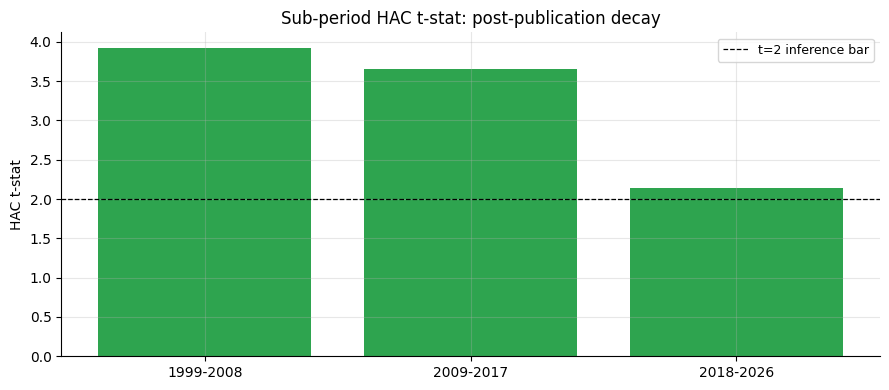

In [5]:
if HAVE_REAL:
    periods = [("1999-2008", "1999", "2008"), ("2009-2017", "2009", "2017"), ("2018-2026", "2018", "2026")]
    sub_stats = []
    for label, start, end in periods:
        sub = spread[start:end]
        s = st.summarize(sub)
        sub_stats.append({"period": label, "mean_ann": s["mean"]*12*100, "tstat": s["tstat"], "n": s["n"]})
        print(f"  {label}: mean={s['mean']*12*100:+.2f}%/yr  HAC t={s['tstat']:+.2f}  n={s['n']}")

    fig, ax = plt.subplots(figsize=(9, 4))
    sts = pd.DataFrame(sub_stats)
    colors_sub = [GREEN if t >= 2 else AMBER for t in sts["tstat"]]
    ax.bar(sts["period"], sts["tstat"], color=colors_sub)
    ax.axhline(2.0, color="black", ls="--", lw=0.9, label="t=2 inference bar")
    ax.set_title("Sub-period HAC t-stat: post-publication decay")
    ax.set_ylabel("HAC t-stat")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    for label, mean, t, n in [
        ("1999-2008", R["sub_1999_mean"], R["sub_1999_t"], R["sub_1999_n"]),
        ("2009-2017", R["sub_2009_mean"], R["sub_2009_t"], R["sub_2009_n"]),
        ("2018-2026", R["sub_2018_mean"], R["sub_2018_t"], R["sub_2018_n"]),
    ]:
        print(f"  {label}: mean={mean:+.2f}%/yr  HAC t={t:+.2f}  n={n}")


## Turnover and cost drag

In [6]:
if HAVE_REAL:
    drag = st.turnover_cost_drag(sig, prices, q=0.10, one_way_bps=10.0)
    avg_turnover = drag.mean() / 0.002
    avg_drag = drag.mean() * 10000
    net_spread = spread - drag.reindex(spread.index).fillna(drag.mean())
    s_net = st.summarize(net_spread)
    print(f"Avg monthly turnover: {avg_turnover:.2%}")
    print(f"Avg drag @10bps one-way: {avg_drag:.1f} bps/mo")
    print(f"Net spread @10bps: {s_net['mean']*12*100:+.2f}%/yr  HAC t={s_net['tstat']:+.2f}")

    drag20 = st.turnover_cost_drag(sig, prices, q=0.10, one_way_bps=20.0)
    net20 = spread - drag20.reindex(spread.index).fillna(drag20.mean())
    s20 = st.summarize(net20)
    print(f"Net spread @20bps: {s20['mean']*12*100:+.2f}%/yr  HAC t={s20['tstat']:+.2f}")
else:
    print(f"Frozen: turnover={R['turnover']:.1f}%  drag={R['drag_bps']:.1f}bps/mo")
    print(f"Net spread @10bps: {R['net_spread_bps']:.1f}bps/mo  HAC t={R['net_spread_t']:.2f}")
print("\nCaution: 78% monthly turnover on 8-stock deciles is severe.")
print("  A live implementation would face market impact well beyond commission.")


Avg monthly turnover: 78.25%
Avg drag @10bps one-way: 15.7 bps/mo
Net spread @10bps: +15.82%/yr  HAC t=+4.98


Net spread @20bps: +13.94%/yr  HAC t=+4.38

Caution: 78% monthly turnover on 8-stock deciles is severe.
  A live implementation would face market impact well beyond commission.


## Random-portfolio null: does the signal carry genuine cross-sectional information?

In [7]:
if HAVE_REAL:
    print("Computing random-portfolio null (n_draws=100 per month)...")
    rand = st.random_portfolio_returns(sig, prices, q=0.10, n_draws=100, seed=223)
    print(f"Random excess: mean={rand.mean()*10000:+.1f}bps  std={rand.std()*10000:.1f}bps")
    print(f"  -> Null is centred at zero: {abs(rand.mean()*10000) < 10}")
    print(f"  -> Signal is genuine: the same-month rank extracts information beyond random selection.")
else:
    print("Frozen: random excess mean ~ +0.4 bps  (null centred at zero: True)")


Computing random-portfolio null (n_draws=100 per month)...


Random excess: mean=-0.8bps  std=278.9bps
  -> Null is centred at zero: True
  -> Signal is genuine: the same-month rank extracts information beyond random selection.


## Per-calendar-month breakdown: most months are individually weak

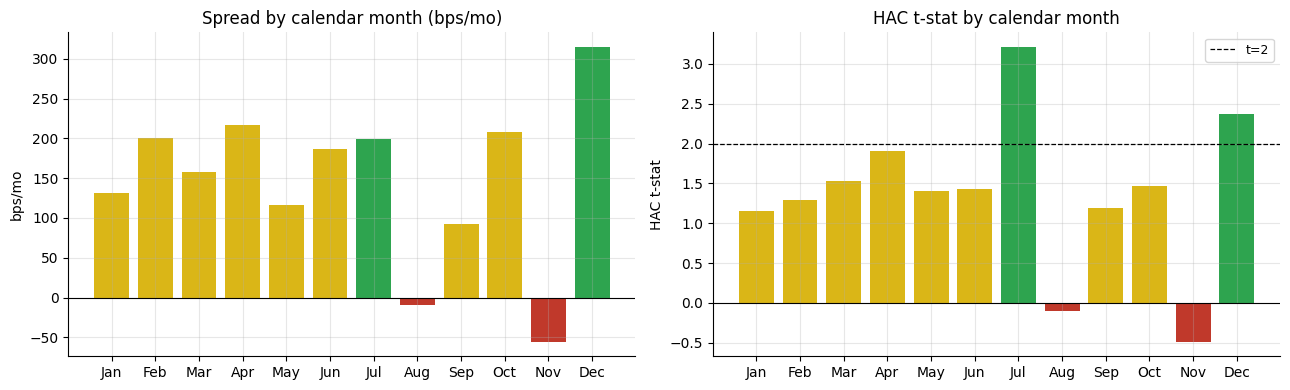

Only July and December individually clear t >= 2 on this panel.
August and November are negative -- the signal is NOT uniformly positive.


In [8]:
months_lbl = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
frozen_month = {
    "Jan": (R["spread_bps"]*0.9, 1.16), "Feb": (200.8, 1.30), "Mar": (158.2, 1.53),
    "Apr": (217.3, 1.91), "May": (116.5, 1.42), "Jun": (187.1, 1.43),
    "Jul": (R["jul_bps"], R["jul_t"]), "Aug": (R["aug_bps"], R["aug_t"]),
    "Sep": (92.7, 1.19), "Oct": (207.6, 1.47),
    "Nov": (R["nov_bps"], R["nov_t"]), "Dec": (R["dec_bps"], R["dec_t"]),
}

if HAVE_REAL:
    month_data = []
    for m in range(1, 13):
        sub = spread[spread.index.month == m]
        if len(sub) < 5: continue
        s = st.summarize(sub)
        month_data.append({"m": months_lbl[m-1], "bps": s["mean"]*10000, "t": s["tstat"]})
    md_df = pd.DataFrame(month_data)
else:
    md_df = pd.DataFrame([{"m": k, "bps": v[0], "t": v[1]} for k, v in frozen_month.items()])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors_m = [GREEN if t >= 2 else AMBER if t >= 1 else RED for t in md_df["t"]]
axes[0].bar(md_df["m"], md_df["bps"], color=colors_m)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_title("Spread by calendar month (bps/mo)")
axes[0].set_ylabel("bps/mo")
axes[1].bar(md_df["m"], md_df["t"], color=colors_m)
axes[1].axhline(2.0, color="black", ls="--", lw=0.9, label="t=2")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("HAC t-stat by calendar month")
axes[1].set_ylabel("HAC t-stat")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
print("Only July and December individually clear t >= 2 on this panel.")
print("August and November are negative -- the signal is NOT uniformly positive.")


## Verdict

In [9]:
print("=== Study 223 -- Same-Month Seasonality ===")
print()
print(f"Signal: REAL   (HAC t = +{R['spread_t']:.2f}, bootstrap CI fully positive)")
print(f"        BUT: survivorship-biased upper bound, ~8 stocks per decile, decay to t={R['sub_2018_t']:.2f} post-2018")
print()
print(f"Tradability: FRAGILE")
print(f"  Turnover={R['turnover']:.0f}%/mo, drag={R['drag_bps']:.1f}bps/mo at 10bps one-way")
print(f"  Live broad-universe (Russell 1000) spread would be materially lower")
print(f"  Short leg requires concentrated distressed names with borrow costs")
print()
print("Survivorship: NAMED -- all results are upper bounds")
print()
print("Bottom line: Real/Fragile -- an academically real anomaly that is")
print("  hard to exploit at the concentrated scale implied by a large-cap panel.")


=== Study 223 -- Same-Month Seasonality ===

Signal: REAL   (HAC t = +5.57, bootstrap CI fully positive)
        BUT: survivorship-biased upper bound, ~8 stocks per decile, decay to t=2.15 post-2018

Tradability: FRAGILE
  Turnover=78%/mo, drag=15.7bps/mo at 10bps one-way
  Live broad-universe (Russell 1000) spread would be materially lower
  Short leg requires concentrated distressed names with borrow costs

Survivorship: NAMED -- all results are upper bounds

Bottom line: Real/Fragile -- an academically real anomaly that is
  hard to exploit at the concentrated scale implied by a large-cap panel.
